<a href="https://colab.research.google.com/github/thedarredondo/data-science-fundamentals/blob/main/Unit8/Unit8NotesAK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

# Unit 8: Bayesian Additive Regression Trees (BART)

Bayesian Additive Regression Trees (BART) can be thought of as a fast approximation of Gaussian Processes (GPs). The implementation of BART that we'll use has various limitations, quirks, and benefits; we'll dicuss them all in this unit.

We'll learn:
- what a decision tree is
- how BART models work, and their relationshipp to decision trees
- how to implement BART in PyMC
- Partial Dependence Plots (pdp)
- Individual Conditional Expecation plots (ice)
- variable importance (vi) plots

Let's get started.

## Theoretical Background: Trees and Forests



### Decision Trees

Think of decision trees as flow charts (the technical term is a graph), but with several restrictions.
- Each node can have only one 'parent' node, but many children.
- We'll focus on binary decision trees, where each node has one parent, and two or zero children
- There is a special node called the 'root' node, with no parents
- Each layer of the tree sorts the predictor values into subsets of the predicted values

All those points are best illustrated with an example.

For our example, we'll use some data on octupus beaks, and try to use upper beak length (estimator) to predict total beak weight (estimand).


In [ ]:
from sklearn import tree

**Make sure to read my comments!**

In [ ]:
#data on octupus beaks
octps = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/octopusbeakweight_nlin.csv')

In [ ]:
#X is our predictor variable, upper beak measurment
X = octps["upBeak"].to_numpy().reshape(-1, 1)
#Y is the predicted variable, total beak weight
Y = octps["totWt"].to_numpy()

In [ ]:
#fits a decision tree. This is analogous to running pm.sample,
#except it only finds the mean . . kinda like that, anyway.
dtree = tree.DecisionTreeRegressor(max_depth=2)
octtree = dtree.fit(X,Y)

#uses the fitted model to predict total weight for various
#unseen upper beak measurements
#This is analogous to a posterior predictive distribution. . .
#. . .if we only found the posterior predictive mean...
#...kinda.
X_test = np.arange(75, 250, 1)[:, np.newaxis]
y = octtree.predict(X_test)

Below is the graph (flow chart-y) version of the decision tree.

[Text(0.5, 0.8333333333333334, 'x[0] <= 159.5\nsquared_error = 1880924.432\nsamples = 30\nvalue = 1927.633'),
 Text(0.25, 0.5, 'x[0] <= 125.5\nsquared_error = 1306456.64\nsamples = 25\nvalue = 1559.6'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 142494.025\nsamples = 9\nvalue = 787.444'),
 Text(0.375, 0.16666666666666666, 'squared_error = 1437160.434\nsamples = 16\nvalue = 1993.938'),
 Text(0.75, 0.5, 'x[0] <= 186.5\nsquared_error = 689807.36\nsamples = 5\nvalue = 3767.8'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 923203.556\nsamples = 3\nvalue = 4063.667'),
 Text(0.875, 0.16666666666666666, 'squared_error = 11449.0\nsamples = 2\nvalue = 3324.0')]

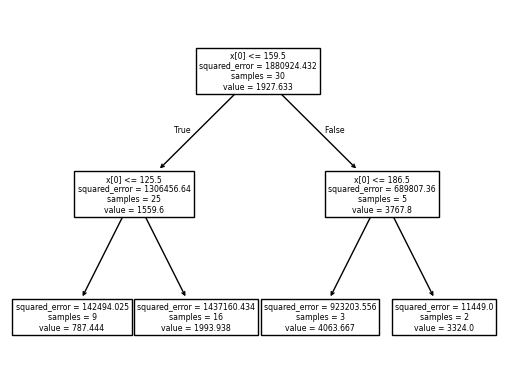

In [ ]:
tree.plot_tree(octtree)

The below graph is similar to if I'd plot just the posterior predictive mean.

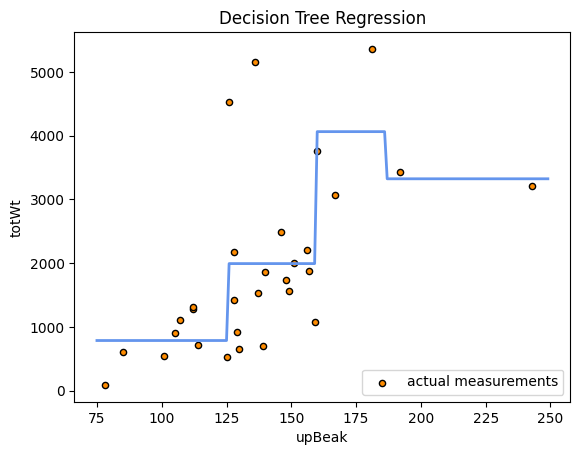

In [ ]:
plt.figure()
plt.scatter(X, Y, s=20, edgecolor="black", c="darkorange", label="actual measurements")
plt.plot(X_test, y, color="cornflowerblue", linewidth=2)
plt.xlabel("upBeak")
plt.ylabel("totWt")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

**Task1**:

The graph (flow-charty) version of the tree has four nodes with no children, often called 'leaf' nodes.

Each of those nodes something that says "value =", then a number.

What are those numbers, and what do they have to do with the psuedo-posterior predictive mean from the scatter plot?

**Ans1**:

Those numbers denote the y values of the four horizontal parts of the blue line plotted over the scatter plot.

Our model, octtree, thinks that, if it can only use four horizontal lines to predict the data, this is where it should put them.

Why four? I specified a max depth of 2; more on that in a second.

**Task2**:

There are three other nodes in the graph (flow chart-y) version of the decision tree.

These start with a text that reads "x[0] <=" followed by a number.

What do these numbers mean, and what do they have to do with the psuedo-posterior predictive mean (the blue line) from the scatter plot?

**Ans2**:

Those numbers correspond to the three vertical lines in the psuedo-posterior predictive mean.

Our model, ```octtree```, thinks that, if it can only use three vertical lines to predict the data, this is where it should put them.

Why three? There are three "splits" in the graph version of the tree; this is the max number of "splits" with a max depth of 2.

**Task3**:

There are two other numbers in each node: "squared error" and samples.

What do those mean?

**Ans3**:

Squared error is the difference from the points above and below the relevant horizontal line, squared and then summed. Squared error is the metric ```octtree``` used to decide how to place each of the lines; the decision tree minmizes the squared error by using a bit of calculus.

'samples' refers to how many points fit the criteria of "x[0]<=" while also being closest to "value=".

**Task4**:

Change max_depth to equal 5 in the above code, and the recreate both graphs.

What changes?

What did max_depth do?

**Ans4:**

max_depth changes how many layers our tree can have. We can think of tree depth as the number of generations of children the root node has. Or, you can think of it as the maximum number of nodes you can move to while only moving "down" the tree

More layers means the our tree can capture more patterns in the data.

**Task5**:

Was increasing the depth of the tree a good idea for this data set?

Why or why not? Try to use one of "underfitting" or "overfitting" in your answer.

**Ans5**:

Bad idea. Any more than depth 2 would be overfitting, for this data set. There are not enough data points to justify giving the model more complexity.

This gets at the main weakness of individual decision trees: they are extremely prone to overfitting, and will completely memroize the given set of data--and therefore be unable to generalize--if you let them.

**Task6:**

Name some pros and cons to using a decision tree. Think about what they do better than other models you've seen, and what they do worse.

**Ans7**:

Decision trees are fast, for two reasons:
- they only calculate a pseudo-posterior mean and pseudo-posterior predictive mean.
- Their decision rules (such as: is something <= something else) are easy to compute.

Both those things can be good and bad for other reasons as well.

The second point first: using a less than or equal to decision rule is excellent for certain problems, and almost impossibly hard for others. This simple, binary way of making decisions also leads to bias, especially when trees are used to classify groups that might be mixed together in complex ways.

Trees tend to be biased in unhelpful ways--but they are transparent about it! Whatver rules a tree decides to make, we can always see its exact reasioning through the graph version of the tree (the flow charty one).

Now to cover pseudo-posterior-ness. Almost all traditional machine learning models suffer from this problem: they ignore variation, so that they can speedily calculate something similar to the posterior or posterior predictive mean.

Basically, they trade in the ability to say how likely we are to be wrong, for SPEED. Only reporting a single blue line gives the illusion of certainty/objectivity. Remember, no model, no matter how good it looks or preforms, is objective.

### Random Forests (RF) and BART

A randomized decision tree on it's own needs lots of care and direction to make sure it doesn't overfit--but a whole bunch of decision trees with randomized root nodes, added together, police themselves. Any method that combines the results of multiple randomized decision trees is called a Random Forest (RF). RFs turn out to be pretty accurate, and also one of the more interpretable model types, thanks to being built from decision trees. Increasing the number of trees can make RFs very accurate, and RFs can be exceptionally fast to fit if the number of trees isn't too big.

Why is combining trees so much better? If we ensure that there's a diversity of trees (ensure they aren't all making similar decisions), then each tree is picking up on a different pattern in the data. Combining the results of the trees combines all the patterns each tree picked up, resulting in a model that "knows" about all of the patterns and can make better predictions. This is called ensemble learning, where a bunch of weak learners are combined to result in more accurate predictions.

At least, that's what we hope happens. There's no guranttee that each tree will pick up something unique about the data. Luckily, we can ecourage our trees to find different patterns by using a BART model.

Here's how: In addition to the randomized root nodes of a a basic RF, BART builds its trees in a sort of sequential manner. BART actually starts with all the trees it needs, but then randomly alters each tree based on the other trees. The "based on the other trees" bit ensures that BART is encouraging the growth of different trees. This idea is called boosting.

BART goes further though; it selects each change to one of its trees as part of an MCMC. This ensures that the whole BART model is a sample from some posterior distribution of possible random forests. You can find a slightly more in depth summary of the BART model as described [here](https://www.youtube.com/watch?v=xWhPwHZF4c0).

There's a final step also unique to BART, that the video above doesn't really cover: BART puts regularizing priors on the depth of each decision tree, and on the magnitude of the leaf nodes. The priors over the depth helps ensure that all the trees will be shallow, that the depth will be much less than the number of data points.
Priors on the leaf nodes ensures that our model only explores near the actual data; the leaf node priors are more traditional regularizing priors.



#### Why all the background on how BART works?

BART is a particularly good example of the algorithm buidling process. It started with something that works with many flaws (Decision Trees), imporved to something that works pretty well on its on (RFs), but kept adding things that helped either reduce underfitting (boosting) or reduce overfitting (MCMC, priors). The result is a flexible model that can accurately fit data *and* that we don't have to spend forever tuning.

That push to make a better algorithm happened to create something that approximates a known mathematical object: a BART model with infinite trees is a nowhere differentiable Guassian Process. BART models are often much faster than any type of GP, and *way* easier to use. They are also simple to interpret, b/c their building blocks, decision trees, are easy to interpret.

Additionally, BART-like models seem to perform much better than anything else at causal inference problems. I don't know if anyone is quite sure why yet (maybe it has something to do with the sequential nature of defining the trees, combined with the tree-graph sturcture itself??).

One last time: people invented a good model by considering how to best balance underfitting, overfitting, speed, and interpretability.

## Implementing BART in PyMC

Armed with knowledge of how BART works and why we should use it, let's build a model with it.

### Octupus BART

First is some preliz stuff I used to come up with a decent likelihood. You don't need to run it, I just thought I'd leave it here so y'all could see a bit of my thought process.

In [ ]:
import preliz as pz

(array([4., 7., 5., 5., 2., 2., 2., 0., 1., 2.]),
 array([  91.,  618., 1145., 1672., 2199., 2726., 3253., 3780., 4307.,
        4834., 5361.]),
 <BarContainer object of 10 artists>)

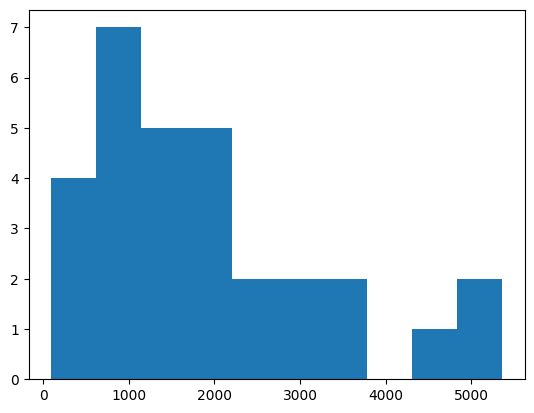

In [ ]:
plt.hist(octps.totWt)

(Gamma(alpha=1.9, beta=0.0011), <Axes: >)

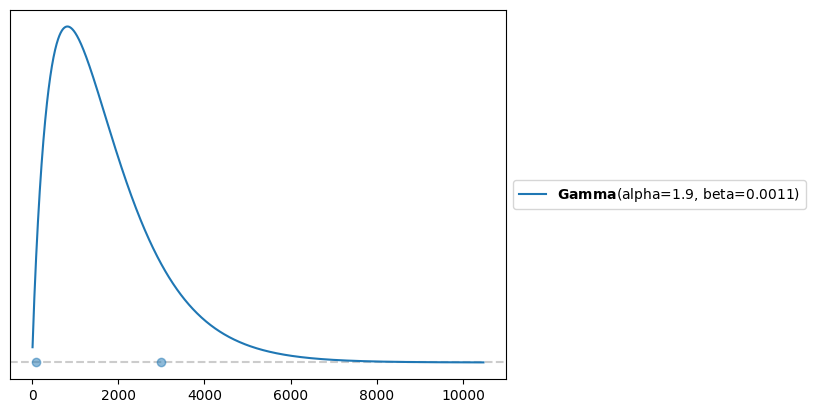

In [ ]:
pz.maxent(pz.Gamma(), 100, 3000, 0.85)

<Axes: >

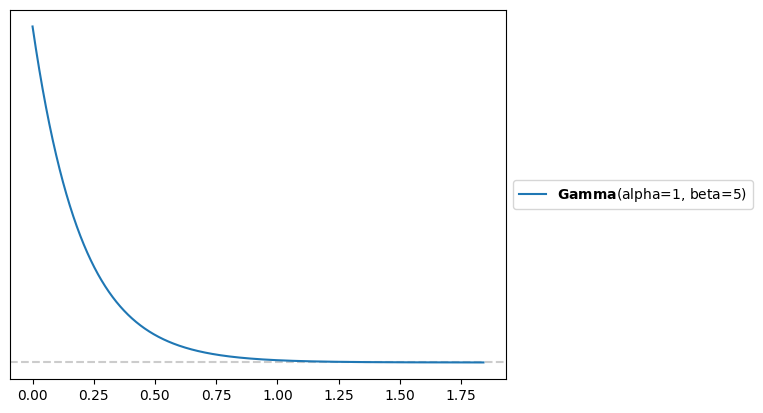

In [ ]:
pz.Gamma(1,5).plot_pdf()

#### A more thoughtful look at the Octopus Data

Now that we're gonna make an actual model, let's take a proper tour of the data we're playig with.

We never looked at the actual dataframe, which was bad form. Let's do it now.

In [ ]:
octps.head()

,totWt,upBeak,loBeak,latWall
0,91,78,78,74
1,532,125,120,131
2,537,101,92,138
3,605,85,107,135
4,647,130,101,155


We should make a pair plot and causal diagram too.

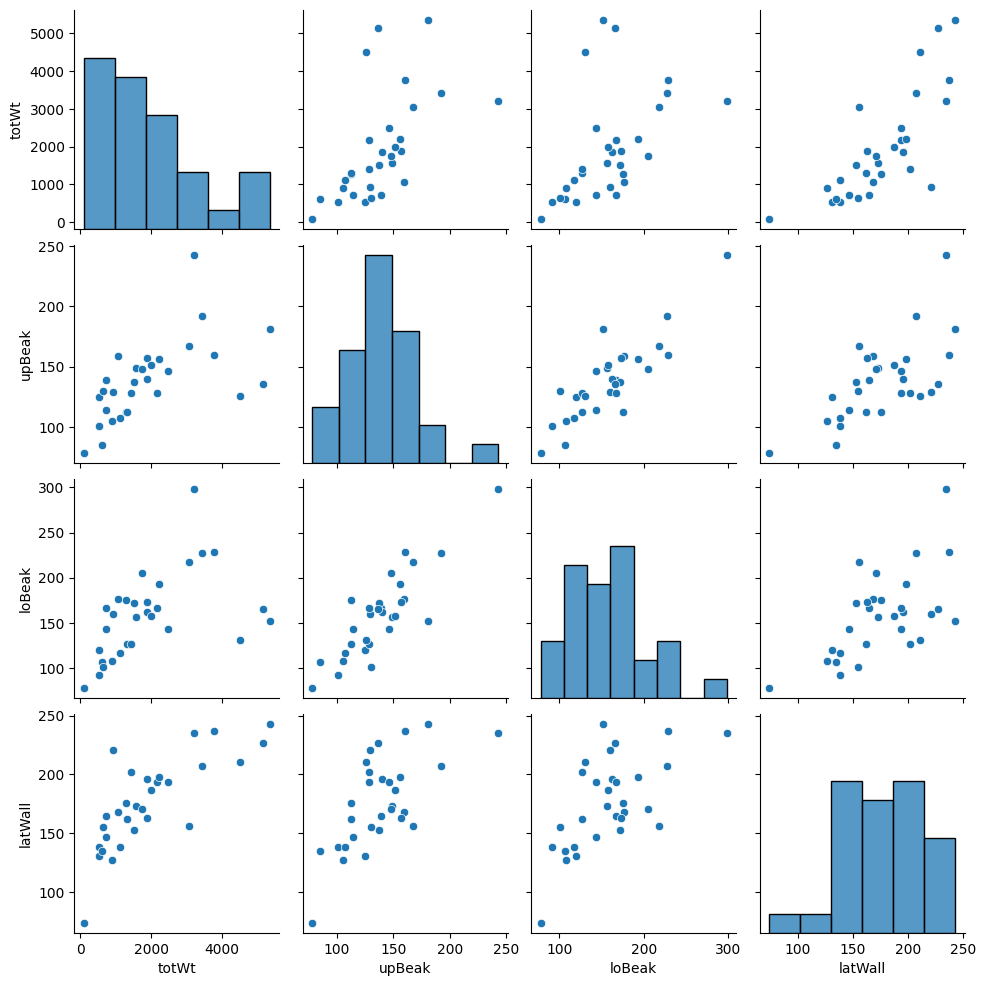

In [ ]:
sns.pairplot(octps)

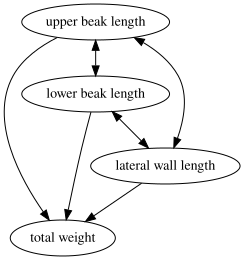

In [ ]:
octodag = gv.Digraph(name="OctoDAG")

octodag.node('T','total weight')
octodag.node('U','upper beak length')
octodag.node('L','lower beak length')
octodag.node('W','lateral wall length')

octodag.edge('U','L', dir = 'both')
octodag.edge('L','W', dir = 'both')
octodag.edge('U','W', dir = 'both')
octodag.edges(['UT','LT','WT',])

octodag

I don't know enough about octopuses, beaks, or octopus beaks to try to even guess at the causal direction between upper, lower and lateral wall. They definitely interact though, as seen from the pair plot.

I'm more comfortable assuming that the beak length measurements cause weigth--this is like saying height causes weight in a person.

The below code is just here to remind you what X and Y are. It also has features commented out; that can be a nice way to put multiple estimators/predictiors into a BART model.

In [ ]:
#features = ["upBeak", "loBeak", "latWall"]

X = octps["upBeak"].to_numpy().reshape(-1, 1)
Y = octps["totWt"].to_numpy()

#### Making our first octopus beak model

**Task7**:

Examine the model below. Is the BART part of the model a prior, or a likelihood?

Were GPs priors, or likelihoods?

**Ans7**:

BART models are approximations of nowhere differentiable GPs, and GPs were priors, so BART models are priors!

At least in this model, and other models we'll use. Theoretically, there's no reason we couldn't have a GP as a likelihood--but I've never heard or seen anyone consider attempting such a thing. Nor do I have any idea how to implement such a model.

I will comment some more on the model below.

First, BART models work with any pymc likelihood. I chose a gamma likelihood because that's what the histogram of total weights looked like to me.

Second, I needed to do some log and exp shenanigans because my values--and my likelihood--are all positive. This implementation of BART needs to range over the positive and negative real numbers.

In [ ]:
with pm.Model() as model_octps:
    s = pm.HalfNormal('s',1000)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y)
    idata_octps = pm.sample(compute_convergence_checks=False)

In [ ]:
#generate the posterior predictive dist
pm.sample_posterior_predictive(idata_octps,model_octps, extend_inferencedata=True)

<Axes: xlabel='y'>

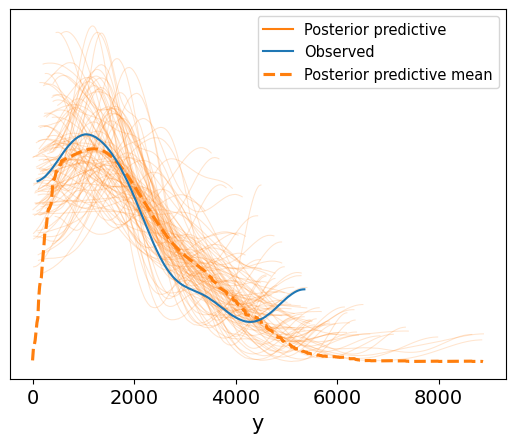

In [ ]:
#plot posterior predictive
az.plot_ppc(idata_octps, num_pp_samples=100, colors=["C1", "C0", "C1"])

In [ ]:
posterior_mean = idata_octps.posterior["μ"]

μ_hdi = az.hdi(ary=idata_octps, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_octps, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.10/dist-packages/arviz/plots/hdiplot.py:161: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


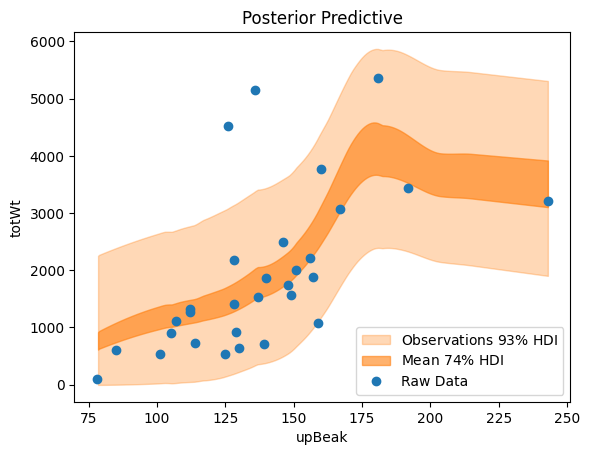

In [ ]:
idx = np.argsort(X[:, 0])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior Predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(octps["upBeak"], octps["totWt"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="upBeak",
    ylabel="totWt",
);

**NOTE**: Because BART models--and random forests in general--are just a bunch of horzontal and vertical lines taped together, they have a bias towards "flatness" (or parallelness to the predictor) on the left and right edges of any predictive plot.

**Task8**:

Comment on the fit of the above posterior predictive check. Is it good, bad, or ugly?

**Ans8**:

I kinda like it, even though I'm not sure if the model is right.

It seems to imply that if a beak gets long enough, it starts to weigh less, even though for shorter beak lengths it thinks longer beaks mean more beak weight.

The part I like though, is how it avoided overfitting, while still capturing nuances and odditites in the data.
For example, it decided the points in the upper left were the weird ones, the ones it considered unlikely, but that the point on the right was indicative of a true trend.

It could very well be wrong, and maybe the far right point and the points in the upper left are all outliers. But I want you to see how the model is flexible enough to capture an unusual shape, without me specifying the shape prior to running the model.

Even better, the model didn't play connect the dots. That's good! It instead decided the two points out left are outliers. We want a model that's willing to give up on predicting a couple of points in order to guess at a larger trend.

# Counties Data, PDPs, ICE, and VI plots

Trigger warning: This analysis covers suicide, and it attempts to find things that influence suicide rates by county in the USA. If you need support in dealing with this topic, reach out. Your voice matters

You can find a full explanation of the counties dataset [here](https://github.com/evangambit/JsonOfCounties?tab=readme-ov-file). The person who curated and intially cleaned the data (Evan Gambit?), did great work, and made this analysis possible. I do not know them, but I am grateful.

After some exploratory data analysis, we'll learn about some new tools unique to BART.

pdps (partial dependence plots) will allow us to see how each predictor variable relates to suicide rate--assuming there are no interactions between predictor variables.

ice (individual condtional expectation) plots will allows to see if their are interactions, and even give us a hint as to the nature of the interactions.

vi (variable importantce) plots will give us an idea of which variables contribute more predictive power.

Altogether, the plots will give us a clearer picture of what our model is, what it values, and what relationships exist in the data.

## Data and Exploratory Data Analysis

First though, is a bit of data cleaning. Not all the columns seem relevant to predict suicide; I arbitrarily chose subset of variables

From those, I drop even more to get to my causal diagram. And my actual models have even fewer than in the causal diagram.

Remember, all models are abritrary, and someone could easily decide a different set of variables are relevant, and end up with a different analysis than me.

In [ ]:
counties = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/counties.csv')

In [ ]:
#the following line will let you see all the variables/columns
#counties.columns.values

In [ ]:
clmn_list = ['name',
             'state',
             'population/2019',
             'health/Violent Crime Rate',
             'life-expectancy',
             'health/Teen Birth Rate',
             'poverty-rate',
             'health/Average Number of Mentally Unhealthy Days',
             'health/% Excessive Drinking',
             'edu/bachelors+',
             'avg_income',
             'deaths/suicides',
             'deaths/firearm suicides',
             'edu/less-than-high-school',
             'elections/2020/gop',
             ]
sad_stats =  counties.loc[:,clmn_list]

I also drop any rows that don't have data for any one of the variables. This removed around 300 to 400 hundred counties. Perhaps having data for those counties would alter the ensuing results?

I won't attempt to answer that question for two reasons:
- creating a model for the missing data would require me to learn about every county that we dropped, and/or learning about the data collection method, which I don't have time for.
- We have a large enough set of data that we can still learn something about the world.

In [ ]:
sdsts_nona = sad_stats.dropna()

I next weight the raw counts by county population. This is not representative of proportion of population (its unclear how deaths by suicide influnce the offical poulation count, for example), but it does allow me to compare large counties to small counties. Unlike with raw counts.

In [ ]:
sdsts_nona.insert(sdsts_nona.shape[1], "suicide/pop", sdsts_nona['deaths/suicides']/sdsts_nona['population/2019'])
sdsts_nona.insert(sdsts_nona.shape[1], "gunsuicide/pop", sdsts_nona['deaths/firearm suicides']/sdsts_nona['population/2019'])
sdsts_nona.insert(sdsts_nona.shape[1], "<hs/pop", sdsts_nona['edu/less-than-high-school']/sdsts_nona['population/2019'])
sdsts_nona.insert(sdsts_nona.shape[1], "gop/pop", sdsts_nona['elections/2020/gop']/sdsts_nona['population/2019'])
sdsts_nona.insert(sdsts_nona.shape[1], "bachelors+/pop", sdsts_nona['edu/bachelors+']/sdsts_nona['population/2019'])
sdsts_nona.insert(sdsts_nona.shape[1], "nogunsuicide/pop", sdsts_nona['suicide/pop'] - sdsts_nona['gunsuicide/pop'])
sdsts_nona.drop(['deaths/suicides', 'edu/less-than-high-school','elections/2020/gop','edu/bachelors+','deaths/firearm suicides',], axis=1, inplace=True)

In [ ]:
#this column name is too dang long, so I shorten it
sdsts_nona.rename(columns={'health/Average Number of Mentally Unhealthy Days':'mentUnhealth','health/Teen Birth Rate':'teenBirth'}, inplace=True)

Here's what the final dataset looks like

In [ ]:
sdsts_nona.head()

,name,state,population/2019,health/Violent Crime Rate,life-expectancy,teenBirth,poverty-rate,mentUnhealth,health/% Excessive Drinking,avg_income,suicide/pop,gunsuicide/pop,<hs/pop,gop/pop,bachelors+/pop,nogunsuicide/pop
1,lancaster county,NE,319090,325.955385,80.46,14.323427,10.7,3.826857,25.446613,49889,0.000105,0.000045,0.000020,0.219662,0.000124,0.000059
3,keith county,NE,8034,105.741121,79.24,23.427041,11.1,3.773762,24.073685,45896,0.000172,0.000113,0.001058,0.441125,0.002552,0.000059
4,phelps county,NE,9034,97.097853,79.86,16.500000,10.0,3.729252,23.178963,52792,0.000121,0.000074,0.000742,0.460151,0.002601,0.000047
5,webster county,NE,3487,110.420980,78.78,15.325670,12.3,3.673882,22.241705,48607,0.000232,0.000137,0.001778,0.433324,0.006596,0.000096
6,dakota county,NE,20026,234.146341,78.39,33.467202,10.6,3.402369,18.172697,41831,0.000090,0.000050,0.001173,0.196045,0.000649,0.000040


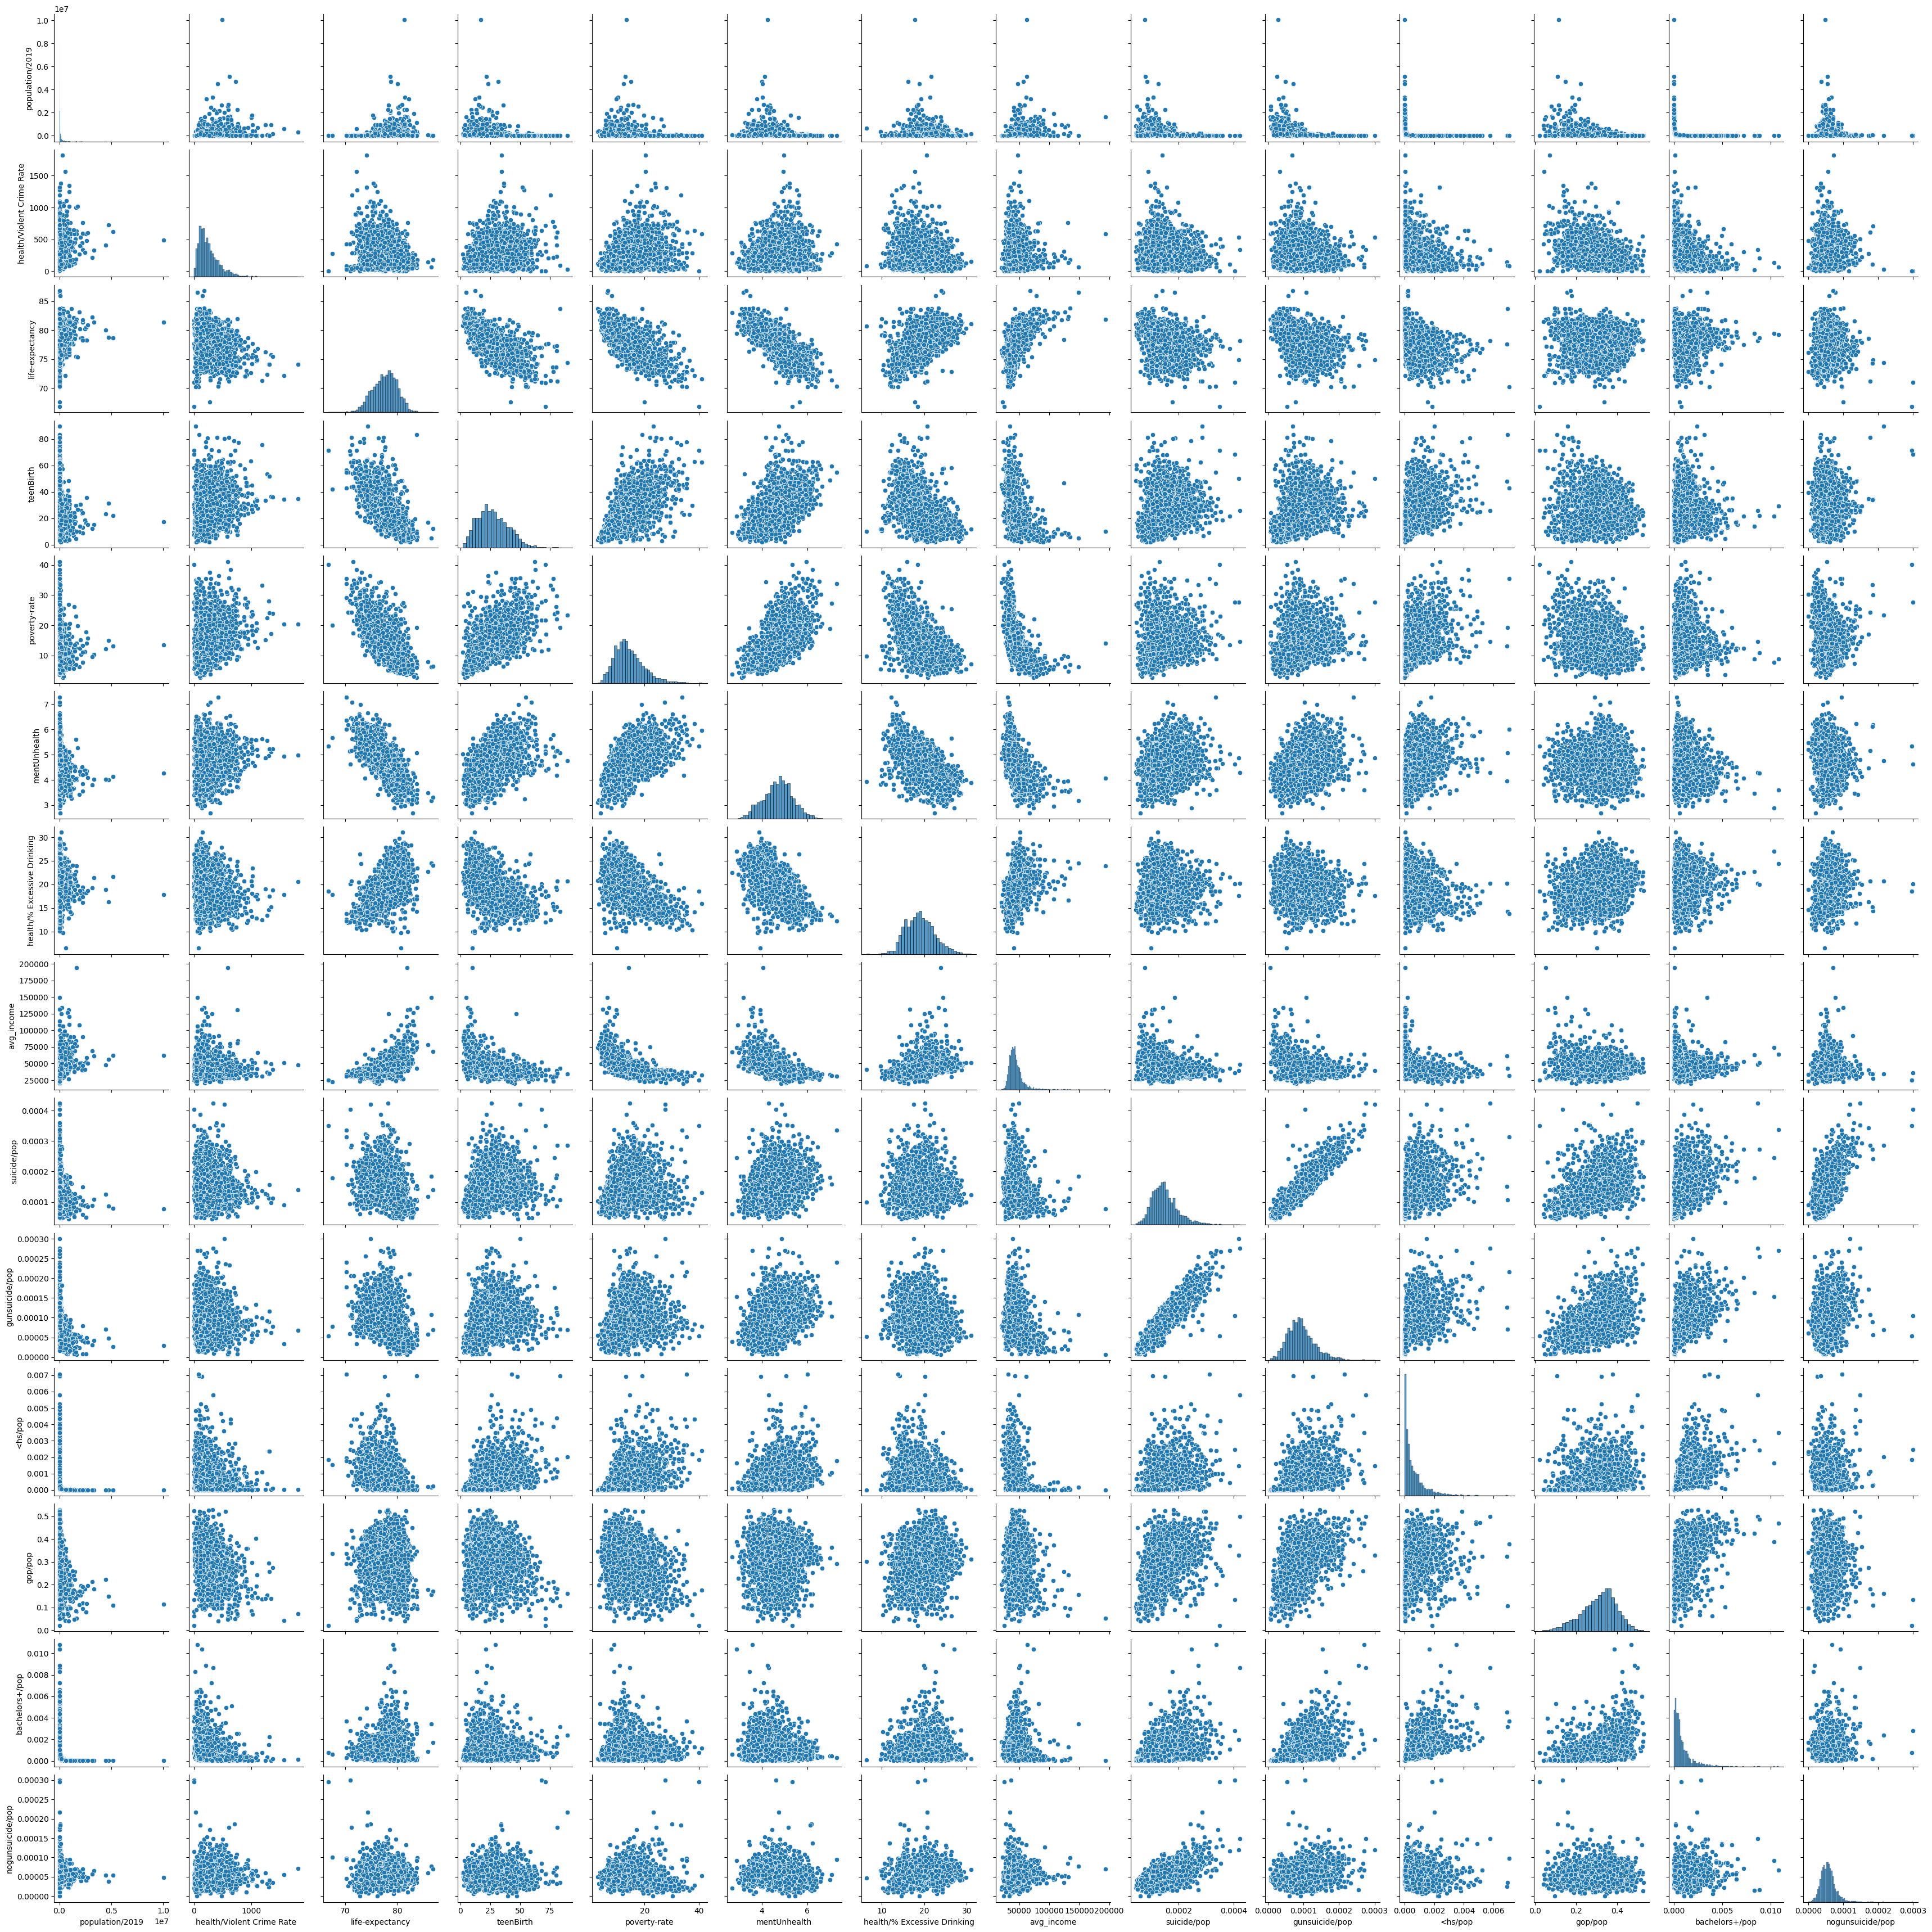

In [ ]:
sns.pairplot(sdsts_nona)

Causal diagram time--but to make it easier on myself, I'm only going to include: gun suicide rate, no gun suicide rate, teen birth rate, poverty rate, number of mentally unhealthy days, proportion with less than a highschool education, and proportion who voted for the GOP in the 2020 electio.

Note that no gun suicide rate is literally suicide rate subtracted by firearm suicide rate.


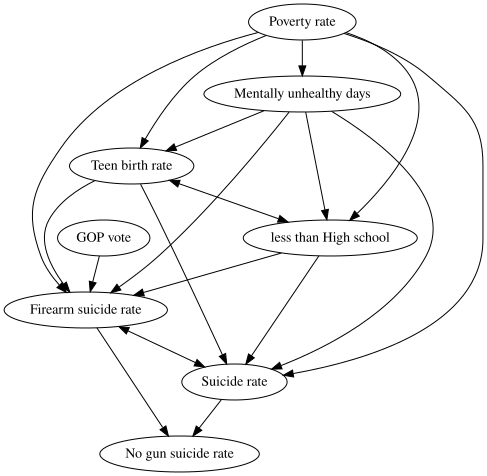

In [ ]:
#c for counties
cdag = gv.Digraph(name="CountiesDAG")

cdag.node('S','Suicide rate')
cdag.node('F','Firearm suicide rate')
cdag.node('N','No gun suicide rate')
cdag.node('T','Teen birth rate')
cdag.node('P','Poverty rate')
cdag.node('M','Mentally unhealthy days')
cdag.node('H','less than High school')
cdag.node('G','GOP vote')

cdag.edge('F','S', dir = 'both')
cdag.edge('T','H', dir = 'both')
#cdag.edge('U','W', dir = 'both')
cdag.edges([
    'SN','FN','TS','MS','PS','HS','TF','MF','PF','HF','GF','PM','PT','PH','MH','MT',
    ])

cdag

**Remember, the above graph is a visualization of MY *assumptions*. It does not represent fact.**

Now for some spoilers--shout out to former student Alex Hersh for discovering this in the eleventh hour of his Unit 8 project; I didn't even have the firearm suicide variable in my original analysis.

Note in the above causal diagram that I only have GOP vote causing firearm suicide rate, not suicide rate, despite the fact that suicide rate and GOP vote appear correlated in the pair plot. I assume that people who vote GOP have more guns than none GOP voters, and I'm noticing that there is no correlation between no gun suicide rate and GOP.

These points might be made clearer by examining the plots below.

<Axes: xlabel='gop/pop', ylabel='suicide/pop'>

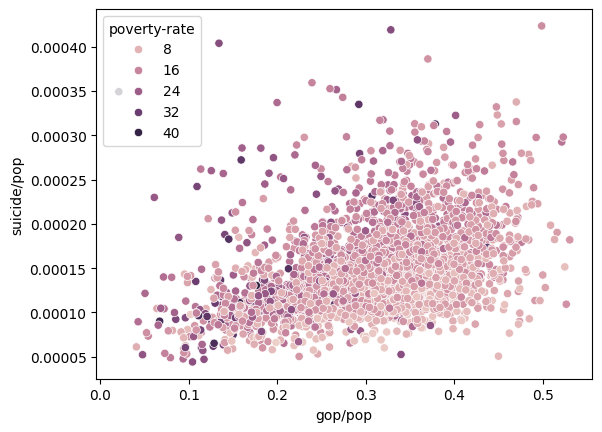

In [ ]:
sns.scatterplot(data = sdsts_nona, y = 'suicide/pop', x = 'gop/pop', hue = 'poverty-rate')

<Axes: xlabel='gop/pop', ylabel='nogunsuicide/pop'>

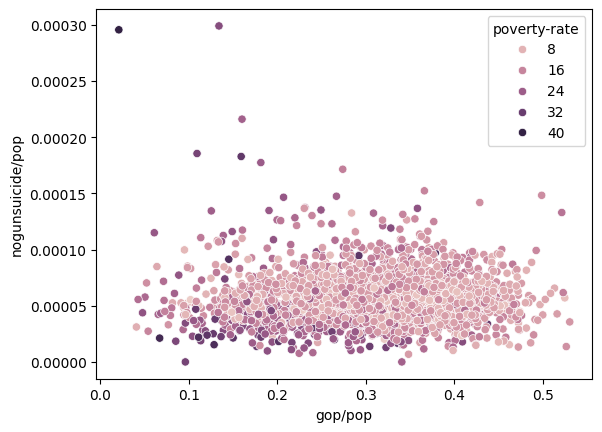

In [ ]:
sns.scatterplot(data = sdsts_nona, y = 'nogunsuicide/pop', x = 'gop/pop', hue = 'poverty-rate',)

### Prep Data for BART Model

After the exploratory data analysis and causal diagramming, I only used teen birth rate, poverty rate, number of mentally unhealthy days, proportion with less than a highschool education, and proportion who voted for the GOP in the 2020 election to predict suicide rate.

I am purposely including GOP in here, even though my causal diagram says not to. This is to:

1. Show what can happen when I make a poor causal assumption
2. Own that I may this mistake on my first pass with this data; I didn't make a causal diagram, and thus missed a key insight.

In [ ]:
#Combine all my estimator variables into one dataframe
X = sdsts_nona[[
             'teenBirth',
             'poverty-rate',
             'mentUnhealth',
             '<hs/pop',
             'gop/pop',
             ]]
#Define my estimand as Y
Y = sdsts_nona['suicide/pop']

## BART Model (predicting suicide rate)

Here's the model, in a svelte six lines of code.

Suicide rate is again all positive (like octupus beak weight), so I use a gamma likelihood. There are also the same log and exp shenanigans from before; these serve to make suicide rate go into the negatives, b/c BART is a real numbers 4eva type of gal.

But seriously, the pymc implementation of BART needs to have its predicted range over positive and negative values, so we have to do this for any all positive support likelihood. I probably could have gotten away with using a normal likelihood--the histogram for suicides isn't that skewed--but I wanted to do my best.

In [ ]:
with pm.Model() as model_counties:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_counties = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_counties,model_counties, extend_inferencedata=True)

Some of y'all may look at this and think "inverse gamma would definitely be better" but every time I tried that likelihood, if gave me strange behavior. Maybe you'll have better luck if you try.

(0.0, 0.0005)

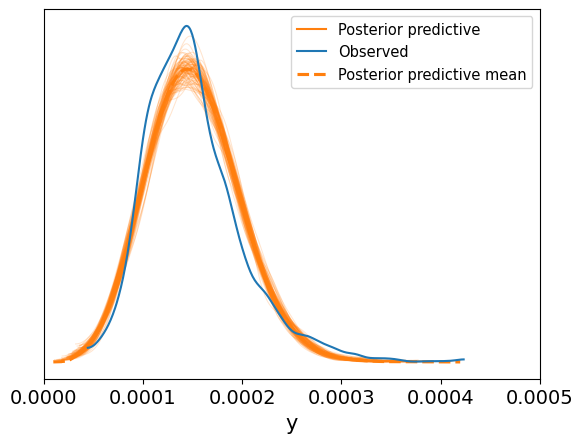

In [ ]:
ax = az.plot_ppc(idata_counties, num_pp_samples=100, colors=["C1", "C0", "C1"])
ax.set_xlim(0.0,0.0005)

The next two code blocks let you plot the posterior predictive for a single one of the variables versus suicide rate. This is less useful, in my opinion, than what follows.

In [ ]:
posterior_mean = idata_counties.posterior["μ"]

μ_hdi = az.hdi(ary=idata_counties, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_counties, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


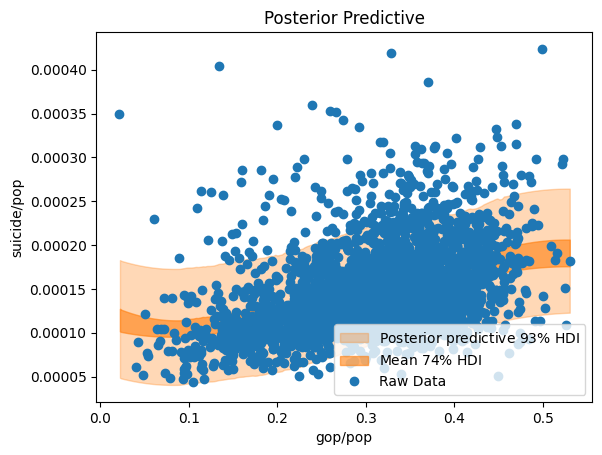

In [ ]:
idx = np.argsort(X.to_numpy()[:, 4]) #grab fifth row
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 4],#grab fifth row
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 4],#grab fifth row
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(sdsts_nona['gop/pop'], sdsts_nona["suicide/pop"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="gop/pop",
    ylabel="suicide/pop",
);

### Partial Dependence Plots (pdp)

This is the beginning of the exciting stuff.

The five graphs below show the association between a predictor varible and the predicted variable, marginalized over the other variables.

Why is that exciting?

It means that these plots show the affect of the proportion who voted for the GOP in 2020 conditioning on the effect of poverty, teen birth rate, reported mental health, and under-education...

...**ASSUMING** that all those predictor variables are mostly independent.

array([<Axes: xlabel='teenBirth'>, <Axes: xlabel='poverty-rate'>,
       <Axes: xlabel='mentUnhealth'>, <Axes: xlabel='<hs/pop'>,
       <Axes: xlabel='gop/pop'>], dtype=object)

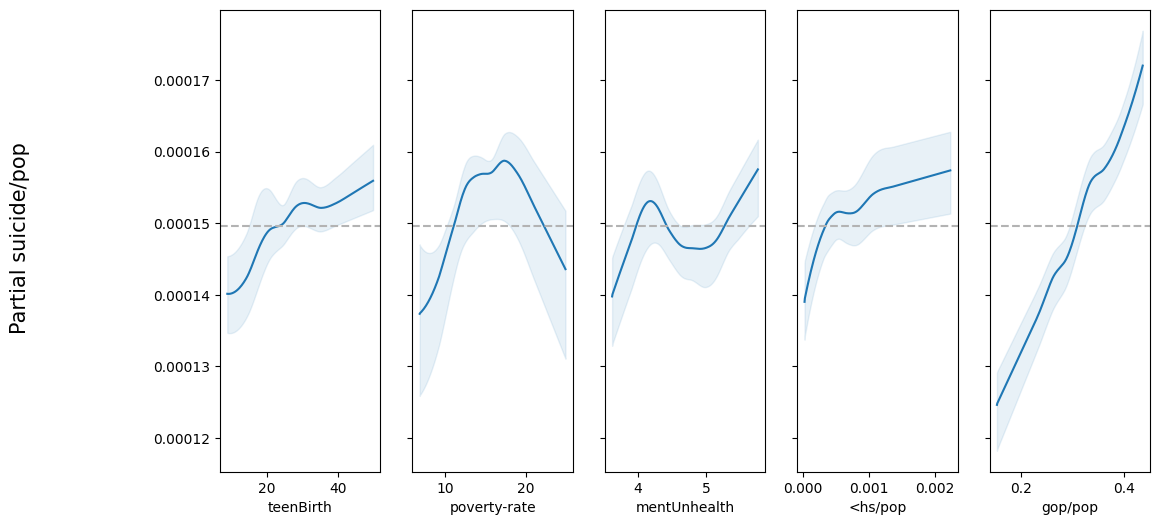

In [ ]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

**Task9**:

Interpret the gop/pop versus suicide rate partial dependence plot, assuming approximate independence between the predictor variables.

 What is the trend?

 Why?

**Ans9**:

If we take the other variables into account, it appears that there is a positive, linear trend between how much a county leaded towards the GOP and suicide rate.

### Individual Conditional Expectation (ice) Plots

Let's drop the assumption that each of the predictor variables is predictor variables is indepentent--b/c they aren't.

For example, education level and GOP voting tendency have had a pretty stable negative association in last couple of decades. And poverty, teen birth rate, education, and mental health are all likely interacting with each other as well.

The first step to account for that is an ice plot.

Look at the lines that make up the ice plots below. The average of all those lines makes up the pdp from above; each line n the ice plot represents a single observation. All those lines averaged are teh pdp.

Individual predictions per data point help us see trends that aren't present in the average.

What do we look for? Parallel-ness: if all the lines in each plot are parallel, then when can ignore the ice plot, and go back to the pdp

array([<Axes: xlabel='teenBirth'>, <Axes: xlabel='poverty-rate'>,
       <Axes: xlabel='mentUnhealth'>, <Axes: xlabel='<hs/pop'>,
       <Axes: xlabel='gop/pop'>], dtype=object)

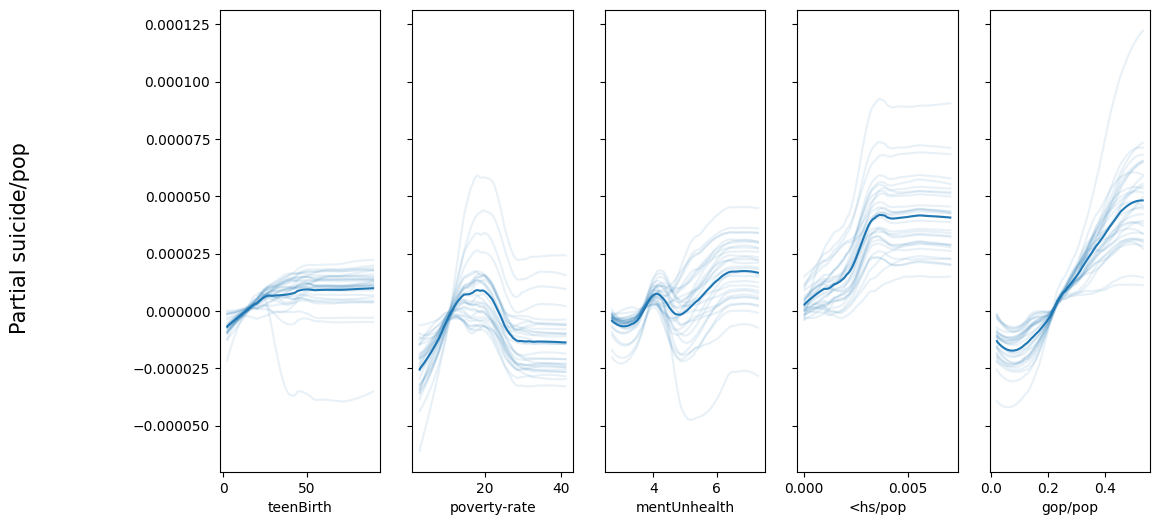

In [ ]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

**Task 10**:

Are the lines within each plot parallel, in the ice plots above?

If they aren't parallel, then describe and interpret the areas in which the lines within the plots are not parallel.

Hint: The lines aren't parallel. Get to describing and interpreting.

**Ans10**:

Poverty rate and mental health seem stable for low numbers. This makes sense to me, since low poverty and low bad mental health days should inutitivly mean lower numbers of sucides.

But for higher rates of poverty and self reported bad mental health days, trends vary a lot, mostly in severity.

This probably means that we need to see poverty interact with at least one other varible, to really see its effect on sucide rate. Likewise for bad mental health days.

Less than highschool educationa and GOP voting are even more fascinating. The trend at low levels of education and low levels of suicide ranges from positive to negative. And for higher levels of low education, there is almost neglible influnce on suicide rate, to a quite dramtic association.

For gop, more gop is associated with more suicide. That trend is highly unstable for low to moderate gop rates, but remarkably stable for high rates of gop.

### Variable Importance (vi) Plots

VI plots, in theory, are supposed to tell us which variables to select if all we care about is prediction accruacy and speed.

For example, the plot below seems to indicate we could probably drop teen birth rate and number of bad mental health days, and get a similar level of performance. It also seems to indicate that gop tendancy and poverty rate give the biggest boosts in performance, as there jumps up in $R^{2}$ are largest.

There are lots of caveats to those interpretations though.

- The order in which the model calculated the $R^{2}$ values matters--and the order is not stable (i.e. it's different from run to run)
- we're using $R^{2}$ instead of elpd_loo, b/c pymc hasn't implemented elpd_loo for BART.
- The order in which BART calculates $R^{2}$ matters a little, and unfortuantely I don't know the scheme for the order it chooses.
- this plot does not show us variable interactions. BART is almost certainly applying the equivalent of variable interactions, but our only hint about what those interactions are comes from the ice plots above

In [ ]:
vi_counties = pmb.compute_variable_importance(idata_counties, μ_, X)

<Axes: ylabel='R²'>

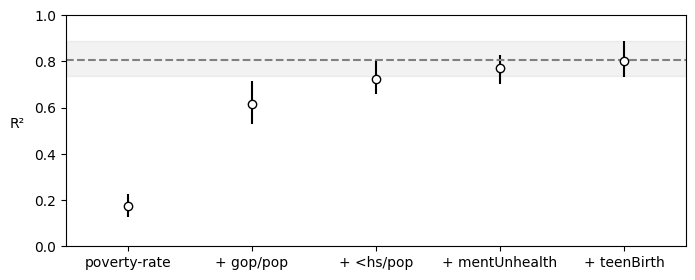

In [ ]:
pmb.plot_variable_importance(vi_counties)

### Conclusion to predicting sucicide rate by county using BART



**Task11**:

Summarize everything we learned from and about model_counties.

**Ans11**:

***The following is my analysis before I made a causal diagram (and before my former student helped me). I leave it unaltered in order to show my thinking when I was making a mistake.***

Gop tendency held a strong positive linear association within the model framework, **which merits further study**. The strength and clarity of this association surprised me.

A model that uses high school education rate, poverty rate, gop tendency in 2020, teen birth rate, and number of mentally unhealthy days does a good job predictiong suicide rate.

More importantly, we got to see that poverty rate and mentally unhealthy days had strong, nonlinear associations with suicide rate within the model framework.

In addition to these strong trends, all the ice plots showed evidence of interaction between the other predictor variables.

The next step would be to build a casual inference inspired glm-like framework to see if we can explicitly pin down the interactions. If we can, they'll be able to answer why we see these strong associations between poverty, bad metnal health days, and gop voting tendency in 2020.

## BART (predicting no gun suicide rate)

Let's do that again, but this time predict no gun suicide rate, and obey my causal diagram.

In [ ]:
#Combine all my estimator variables into one dataframe
X = sdsts_nona[[
             'teenBirth',
             'poverty-rate',
             'mentUnhealth',
             '<hs/pop',
             'gop/pop',
             ]]
#Define my estimand as Y, normalized
Y = (sdsts_nona['nogunsuicide/pop'] - sdsts_nona['nogunsuicide/pop'].mean())/sdsts_nona['nogunsuicide/pop'].std()

In [ ]:
with pm.Model() as model_nogun:
    s = pm.HalfNormal('s',10)
    #I normalized the Y values, so no need for log and exp shenanigans
    μ_ = pmb.BART("μ_", X, Y, m=50)
    μ = pm.Deterministic("μ",μ_)
    #it's not actually normal, but I just want a rough sketch
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y)
    idata_nogun = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_nogun,model_nogun, extend_inferencedata=True)

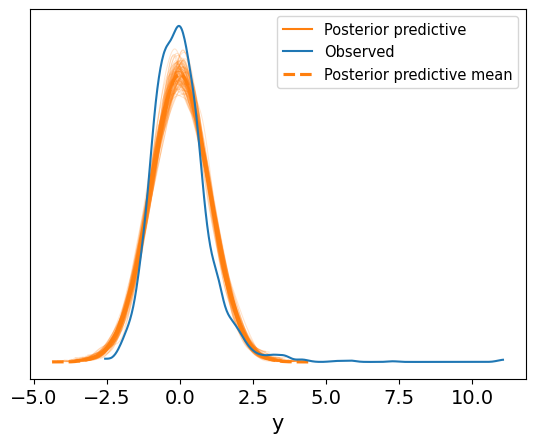

In [ ]:
ax = az.plot_ppc(idata_nogun, num_pp_samples=100, colors=["C1", "C0", "C1"])
#ax.set_xlim(0.0,0.0005)

In [ ]:
posterior_mean = idata_nogun.posterior["μ"]

μ_hdi = az.hdi(ary=idata_nogun, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_nogun, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


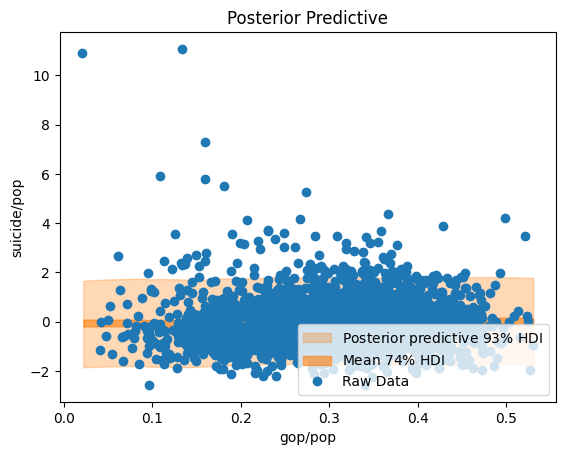

In [ ]:
idx = np.argsort(X.to_numpy()[:, 4]) #grab fifth row
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 4],#grab fifth row
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 4],#grab fifth row
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(sdsts_nona['gop/pop'], Y, "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="gop/pop",
    ylabel="nogunsuicide/pop",
);

array([<Axes: xlabel='teenBirth'>, <Axes: xlabel='poverty-rate'>,
       <Axes: xlabel='mentUnhealth'>, <Axes: xlabel='<hs/pop'>,
       <Axes: xlabel='gop/pop'>], dtype=object)

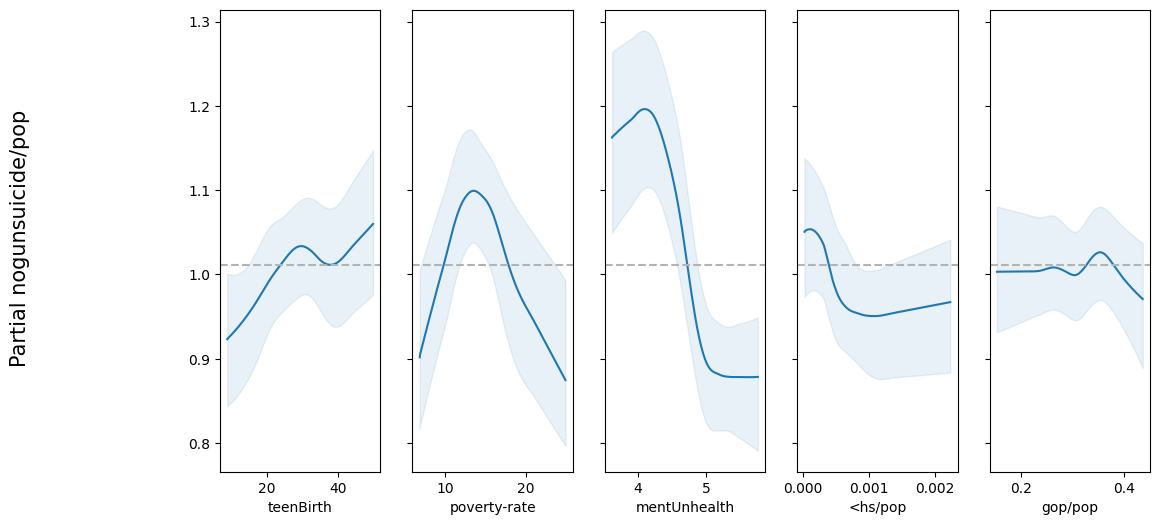

In [ ]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='teenBirth'>, <Axes: xlabel='poverty-rate'>,
       <Axes: xlabel='mentUnhealth'>, <Axes: xlabel='<hs/pop'>,
       <Axes: xlabel='gop/pop'>], dtype=object)

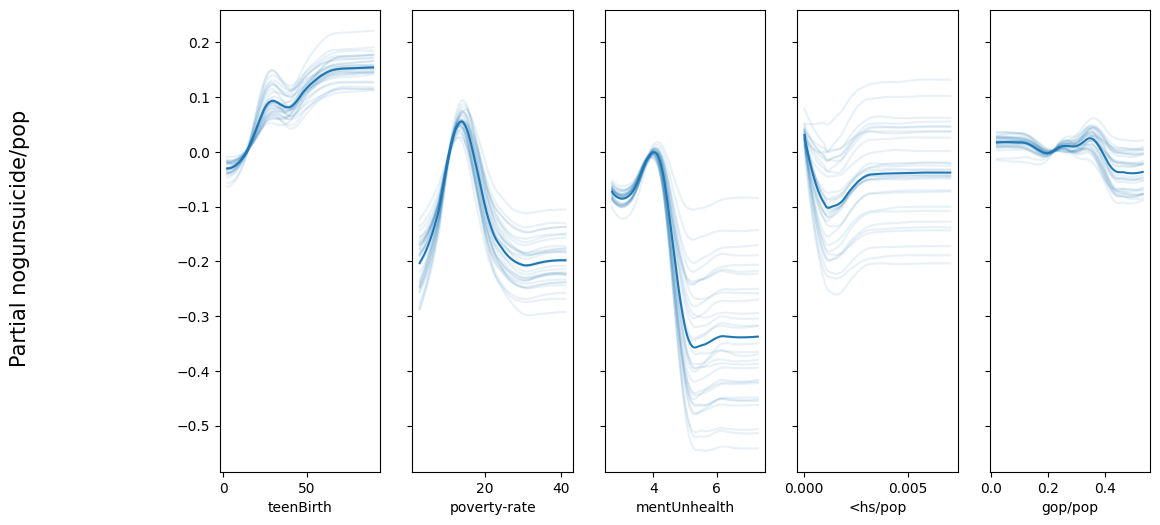

In [ ]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

In [ ]:
vi_nogun = pmb.compute_variable_importance(idata_nogun, μ_, X)

<Axes: ylabel='R²'>

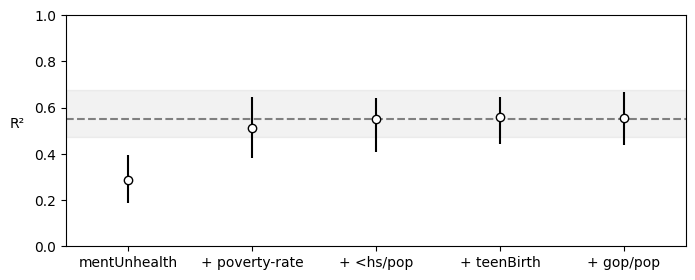

In [ ]:
pmb.plot_variable_importance(vi_nogun)

**Task12:**

Summarize everything we learned from and about model_nogun.

**Ans12**:

Note that none of these conclusions apply to firearm suicides.

- There are much fewer potential interactions; only teen birth rate and GOP have inflection points where the slope of the lines switch. Investigation the interaction between teen birth rate and GOP seems worthwhile.

- GOP voting propensity seems to not affect non gun suicides, with little variation
- Less than highschool education also seems weak, but with lots of variation.

- Mental health is interesting: I think the decline in sucicide rate has to do with the fact that its self reported bad mental health days (I looked up the data source to learn that). I figure that willingness to report a bad mental helath day might help prevent suicide, which would explain the trend, and explain how variable that protecting effect is at high mental health days.

- Poverty rate is also interesting, implying that if a county has a certain poverty rate, suicides are much higher. I'm betting there is some confounder I'm not accounting for there.

- Teen birth rate now looks like a powerful predictor of non gun suicide. Apparently parenting is hard. Dark jokes aside, this one vibes with my intuition: teen pregenancies are often unplanned, and even somewhat shameful in many US communities. I'm not surprised there is a small, if present, affect.

In my mind, the obvious follow up study to this is predicting firearm suicides, since this analysis gave no info on that, and the previous analyis might have been muddled by mixing firearm and non firearm suicides.

## BART (predicting firearm suicides)

That's right, round three.

Seperating firearm and nonfirearm suicides makes sense to me, since firearms are designed to kill people [citation needed].

I'm going to normalize things again, because I'm lazy, and I just want to see the big picture. Ignoring the skew here is a little more egregious (see the histogram in the pair plot); let's see if I get punished for my sloth.

In [ ]:
#Combine all my estimator variables into one dataframe
X = sdsts_nona[[
             'teenBirth',
             'poverty-rate',
             'mentUnhealth',
             '<hs/pop',
             'gop/pop',
             ]]
#Define my estimand as Y, normalized
Y = (sdsts_nona['gunsuicide/pop'] - sdsts_nona['gunsuicide/pop'].mean())/sdsts_nona['gunsuicide/pop'].std()

In [ ]:
with pm.Model() as model_gun:
    s = pm.HalfNormal('s',10)
    #I normalized the Y values, so no need for log and exp shenanigans
    μ_ = pmb.BART("μ_", X, Y, m=50)
    μ = pm.Deterministic("μ",μ_)
    #it's not actually normal, but I just want a rough sketch
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y)
    idata_gun = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_gun,model_gun, extend_inferencedata=True)

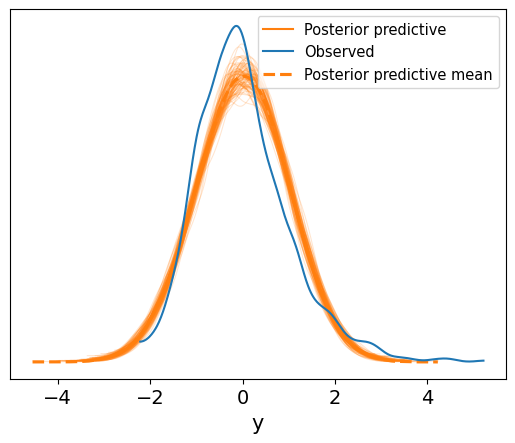

In [ ]:
ax = az.plot_ppc(idata_gun, num_pp_samples=100, colors=["C1", "C0", "C1"])
#ax.set_xlim(0.0,0.0005)

Definitely off on the likelihood, but its good enough for a rough sketch.

In [ ]:
posterior_mean = idata_gun.posterior["μ"]

μ_hdi = az.hdi(ary=idata_gun, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_nogun, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


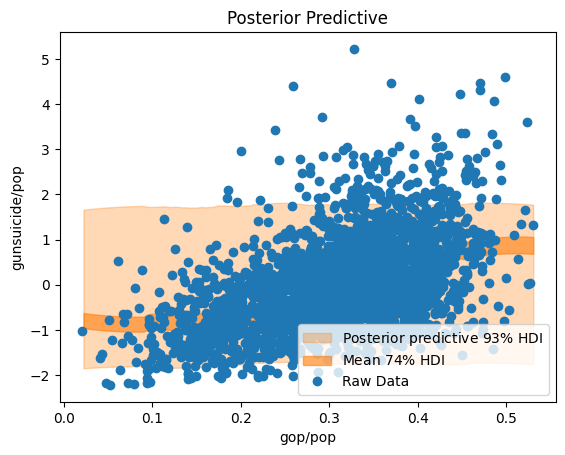

In [ ]:
idx = np.argsort(X.to_numpy()[:, 4]) #grab fifth row
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 4],#grab fifth row
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 4],#grab fifth row
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(sdsts_nona['gop/pop'], Y, "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="gop/pop",
    ylabel="gunsuicide/pop",
);

array([<Axes: xlabel='teenBirth'>, <Axes: xlabel='poverty-rate'>,
       <Axes: xlabel='mentUnhealth'>, <Axes: xlabel='<hs/pop'>,
       <Axes: xlabel='gop/pop'>], dtype=object)

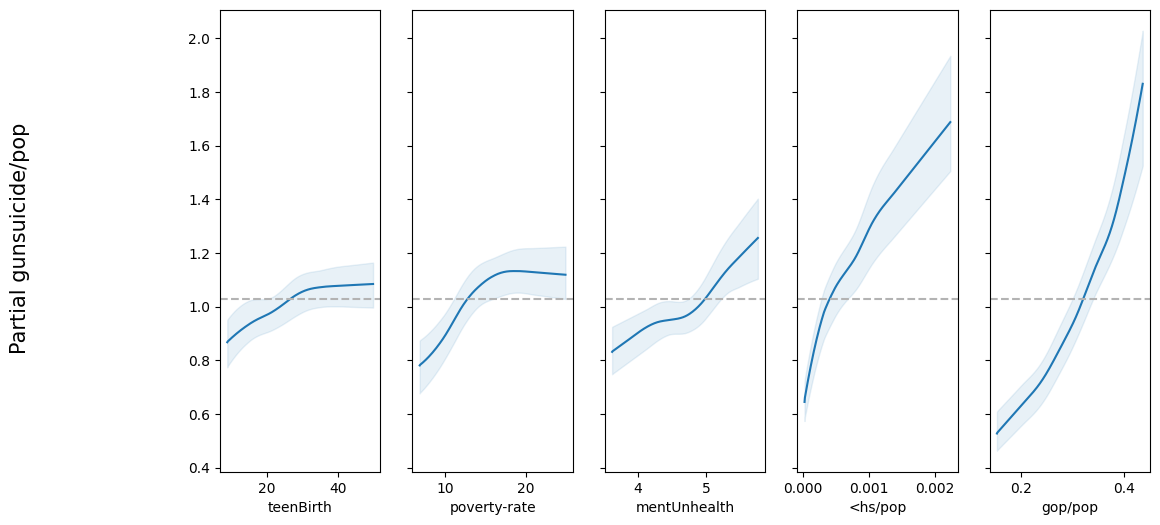

In [ ]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='teenBirth'>, <Axes: xlabel='poverty-rate'>,
       <Axes: xlabel='mentUnhealth'>, <Axes: xlabel='<hs/pop'>,
       <Axes: xlabel='gop/pop'>], dtype=object)

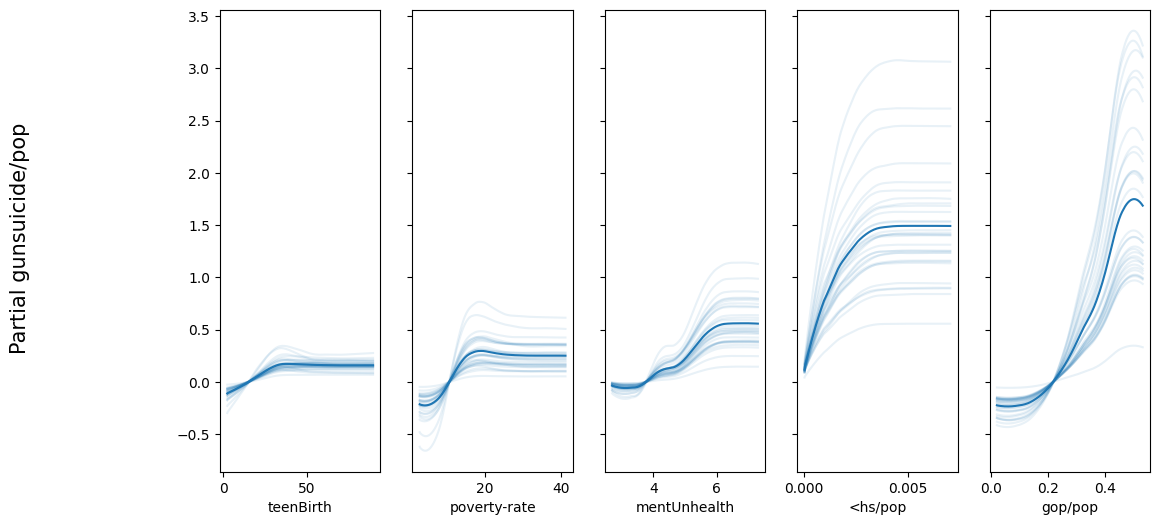

In [ ]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

In [ ]:
vi_gun = pmb.compute_variable_importance(idata_gun, μ_, X)

<Axes: ylabel='R²'>

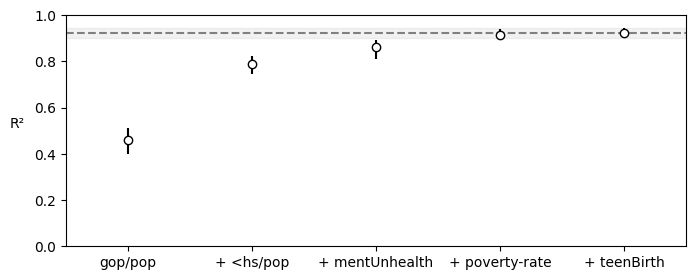

In [ ]:
pmb.plot_variable_importance(vi_gun)

**Task13:**

Summarize everything we learned from and about model_gun.

**Ans13**:

- Unsurprising to me, GOP has strong predictive power on firearm suicides. A firearm suicide isn't possible without a firearm, and GOP voters are more likely to have firearms.

- Surprising to me: less than highschool education had an almost equal affect, and there doesn't appear to be an interaction. The effect has massive variance, but still, its strong. Maybe people with less than a highschool education are more likely to have firearms?

- Self reported mental health days no longer sees to have a protective effect. My guess is that either being the type of person who reports bad mental health days and has a firearm is a bad combination--or that the availibility (and deadly effectiveness) of a firearm more than cancels out any good that comes from telling others how you feel.

- Poverty rate and teen birth seem to have negligible effects, although they do show evidence of interactions. Perhaps those are key interactions with self reported mental health and GOP voting? Further analysis could determine that.

At this point, investigating interactions using a GLM is probably the way to go. The counties data set is huge though, so there is probably more to learn by including more variables, so that's fertile ground for investigation as well.

# Summary

Once again, we've covered a lot of ground.

We put in the work to start understanding the concept of decision trees, how they can flexibly adapt to data, in an interpretable way.

Then we jumped into a theoretical disscussion on how to supe up our decions trees, making them more powerful.

Those fancy, aggregated decision trees were called BART, and they allowed us to quickly create a model which could determine an appropriate non-linear shape, all on its own.

Next, we pivoted to a different application of BART, with multiple predictiors. It still helped to have BART be able to capture non-linear trends, but we also used pdps, ice plots, and vi plots to find out the relationships between several predictor variables and suicide rate by county.

We were able to determine some interesting associations, and also learn that there were many interactions between our predictor variables.

Throughout, we made continual reference to the context of the data and our causal assumptions--no matter haow effective our tools, we still have to think about reality.

BART is a powerful, flexible, and interpretable model. We can use the framework to quickly create a good prediction engine for simple to complex data. We can also use it to learn about relationships in our data.

### What's next?

So, is there anything BART (or random forests) can't do?

BART and RFs can do almost anything a GP can do, which is a lot. But purer GPs are better for time series data, GLMs are better for precisely determing interactions and the nuances of data.

And in the next unit, we'll cover a model type that trades in interpretability for (potentially) the highest predictive power of any model type.

But neural networks are next unit. For now, we still value the interpretability of our model about as much (mayber even a little more) than its predictive power.